In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path
import os

pd.set_option("display.max_colwidth", None)

print("✅ Setup terminé")

✅ Setup terminé


# Notebook EDA + Préparation RAG


In [26]:

# LOAD DATASETS 


import pandas as pd
from pathlib import Path

base_path = Path("C:/Users/skand/OneDrive/Bureau/rag/archive")

files = list(base_path.glob("*.csv"))

print(f"📂 {len(files)} fichiers trouvés")

dfs = []

for file in files:
    try:
        df = pd.read_csv(file)
        df["source_file"] = file.name
        dfs.append(df)
        print(f"✅ Loaded: {file.name} -> {df.shape}")
    except Exception as e:
        print(f"❌ Erreur sur {file.name}: {e}")

data = pd.concat(dfs, ignore_index=True)

print("\n📊 Dataset global :", data.shape)

data.head()

📂 5 fichiers trouvés
✅ Loaded: aa_dataset-tickets-multi-lang-5-2-50-version.csv -> (28587, 17)
✅ Loaded: dataset-tickets-german_normalized.csv -> (2125, 6)
✅ Loaded: dataset-tickets-german_normalized_50_5_2.csv -> (13178, 6)
✅ Loaded: dataset-tickets-multi-lang-4-20k.csv -> (20000, 16)
✅ Loaded: dataset-tickets-multi-lang3-4k.csv -> (4000, 18)

📊 Dataset global : (67890, 19)


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,source_file,business_type,tag_9
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komponenten unserer Infrastruktur betrifft. Betroffene Geräte umfassen Projektoren, Bildschirme und Speicherlösungen auf Cloud-Plattformen. Der Grund für die Annahme ist, dass der Vorfall eine potenzielle Datenverletzung im Zusammenhang mit einer Cyberattacke darstellt, was ein erhebliches Risiko für sensible Informationen und den laufenden Geschäftsbetrieb unserer Organisation bedeutet.\n\nUnsere initialen Untersuchungen haben ungewöhnliche Aktivitäten und Abweichungen bei den Geräten ergeben. Trotz der Umsetzung unserer standardisierten Behebungs- und Eindämmungsmaßnahmen konnte die Bedrohung bislang nicht vollständig eliminiert.","Vielen Dank für die Meldung des kritischen Sicherheitsvorfalls und die Bereitstellung der Übersicht über die betroffenen Geräte sowie der ergriffenen ersten Maßnahmen. Wir erkennen die Dringlichkeit und Schwere der Lage an und setzen alles daran, den Fall prioritär zu bearbeiten. Für eine umgehende Untersuchung benötigen wir zusätzliche Informationen: Bitte senden Sie uns spezifische Protokolle der betroffenen Projektoren, Bildschirme und Cloud-Speichersysteme, inklusive Zeitstempel verdächtiger Aktivitäten sowie ungewöhnlicher Fehlermeldungen. Falls möglich, fügen Sie auch eine Zusammenfassung der bereits durchgeführten Maßnahmen bei.",Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN,aa_dataset-tickets-multi-lang-5-2-50-version.csv,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account management portal, which currently appears to be offline. This outage is blocking access to account settings, leading to substantial inconvenience. I have attempted to log in multiple times using different browsers and devices, but the issue persists.\n\nCould you please provide an update on the outage status and an estimated time for resolution? Also, are there any alternative ways to access and manage my account during this downtime?","Thank you for reaching out, <name>. We are aware of the outage affecting the centralized account management system, and our technical team is actively working to resolve the issue. In the meantime, we suggest using alternative methods to manage your account, with a focus on restoring service as quickly as possible. We will provide an update as soon as the service is back online. We apologize for the inconvenience and appreciate your patience. If you have any further questions, please let us know.",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN,aa_dataset-tickets-multi-lang-5-2-50-version.csv,NaN,NaN
2,Query About Smart Home System Integration Features,"Dear Customer Support Team,\n\nI hope this message reaches you well. I am reaching out to request detailed information about the capabilities of your smart home integration products listed on your website. As a potential customer aiming to develop a seamlessly interconnected home environment, it is essential to understand how your products interact with various smart home platforms.\n\nCould you kindly provide detailed compatibility information with popular smart home ecosystems such as Amazon Alexa, Google Assistant, and Apple?","Thank you for your inquiry. Our products support integration with Amazon Alexa, Google Assistant, and Apple HomeKit. Compatibility details can differ depending on the specific item; please let us know which models you are interested in. The setup process is generally user-friendly but may require professional installation. We regularly update our software to provide enhanced features. For comprehensive information on compatibility with upcoming updates, plea

Comparaison des colonnes entre fichiers


In [27]:
columns_per_file = {}

for file in files:
    df = pd.read_csv(file)
    columns_per_file[file.name] = set(df.columns)

for file, cols in columns_per_file.items():
    print(f"\n📂 {file}")
    print(cols)

common_cols = set.intersection(*columns_per_file.values())
print("\n✅ Colonnes communes :", common_cols)

all_cols = set.union(*columns_per_file.values())

for file, cols in columns_per_file.items():
    print(f"\n❌ Colonnes manquantes dans {file} :")
    print(all_cols - cols)


📂 aa_dataset-tickets-multi-lang-5-2-50-version.csv
{'type', 'queue', 'answer', 'version', 'tag_2', 'language', 'tag_7', 'tag_8', 'tag_5', 'tag_6', 'tag_1', 'tag_4', 'body', 'tag_3', 'subject', 'priority'}

📂 dataset-tickets-german_normalized.csv
{'queue', 'language', 'body', 'subject', 'priority'}

📂 dataset-tickets-german_normalized_50_5_2.csv
{'queue', 'language', 'body', 'subject', 'priority'}

📂 dataset-tickets-multi-lang-4-20k.csv
{'type', 'queue', 'answer', 'tag_8', 'tag_2', 'language', 'tag_7', 'tag_5', 'tag_6', 'tag_1', 'tag_4', 'body', 'tag_3', 'subject', 'priority'}

📂 dataset-tickets-multi-lang3-4k.csv
{'type', 'queue', 'answer', 'tag_8', 'tag_2', 'language', 'tag_7', 'tag_9', 'business_type', 'tag_5', 'tag_6', 'tag_1', 'tag_4', 'body', 'tag_3', 'subject', 'priority'}

✅ Colonnes communes : {'queue', 'language', 'body', 'subject', 'priority'}

❌ Colonnes manquantes dans aa_dataset-tickets-multi-lang-5-2-50-version.csv :
{'tag_9', 'business_type'}

❌ Colonnes manquantes dans

Nombre de tickets par fichier

source_file
aa_dataset-tickets-multi-lang-5-2-50-version.csv    28587
dataset-tickets-multi-lang-4-20k.csv                20000
dataset-tickets-german_normalized_50_5_2.csv        13178
dataset-tickets-multi-lang3-4k.csv                   4000
dataset-tickets-german_normalized.csv                2125
Name: count, dtype: int64


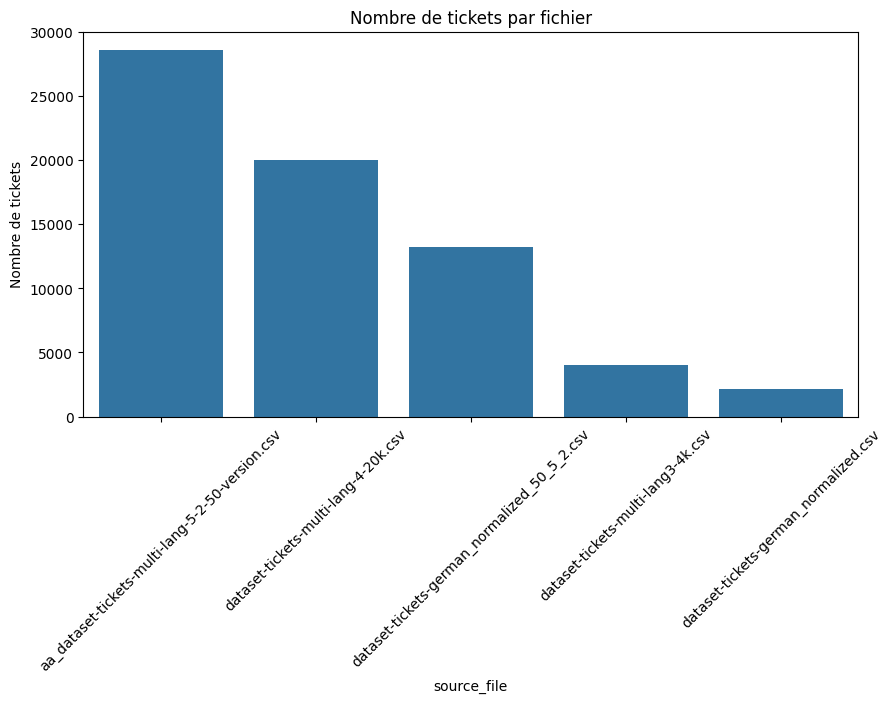

In [28]:
tickets_per_file = data["source_file"].value_counts()

print(tickets_per_file)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(x=tickets_per_file.index, y=tickets_per_file.values)
plt.xticks(rotation=45)
plt.title("Nombre de tickets par fichier")
plt.ylabel("Nombre de tickets")
plt.show()

Distribution des langues

language
de    36477
en    29652
es      812
fr      476
pt      473
Name: count, dtype: int64


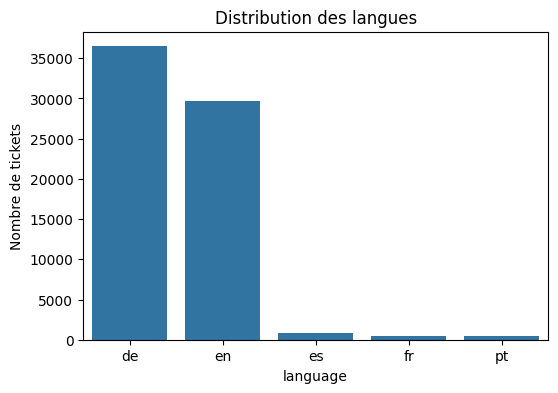

In [29]:
lang_counts = data["language"].value_counts()

print(lang_counts)

plt.figure(figsize=(6,4))
sns.barplot(x=lang_counts.index, y=lang_counts.values)
plt.title("Distribution des langues")
plt.ylabel("Nombre de tickets")
plt.show()

Langues par fichier

language                                             de     en   es   fr   pt
source_file                                                                  
aa_dataset-tickets-multi-lang-5-2-50-version.csv  12249  16338    0    0    0
dataset-tickets-german_normalized.csv              2125      0    0    0    0
dataset-tickets-german_normalized_50_5_2.csv      13178      0    0    0    0
dataset-tickets-multi-lang-4-20k.csv               8077  11923    0    0    0
dataset-tickets-multi-lang3-4k.csv                  848   1391  812  476  473


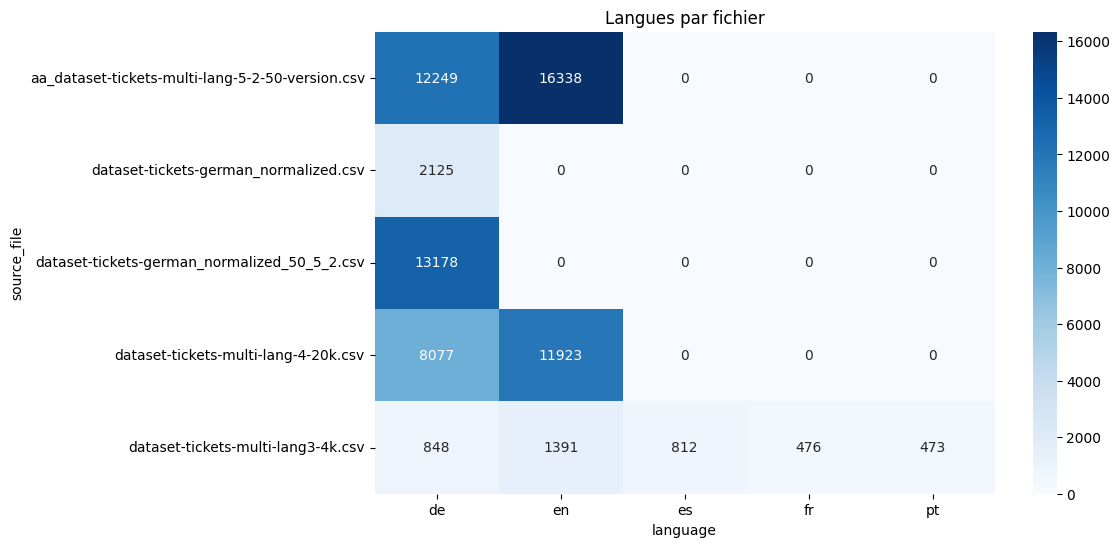

In [30]:
lang_file = pd.crosstab(data["source_file"], data["language"])

print(lang_file)

plt.figure(figsize=(10,6))
sns.heatmap(lang_file, annot=True, fmt="d", cmap="Blues")
plt.title("Langues par fichier")
plt.show()

Analyse des sujets

count    67890.000000
mean        43.513286
std         22.849974
min          0.000000
25%         32.000000
50%         43.000000
75%         56.000000
max        675.000000
Name: subject_length, dtype: float64
subject
Hilfe benötigt               4
Synchronisationsproblem      4
Probleme mit Google Meet     4
Systemausfall                4
Anfrage zur Unterstützung    4
Synchronisationsprobleme     4
Unterstützung benötigt       4
Request for Support          3
Urgent Support Needed        3
Update Request               3
Name: count, dtype: int64


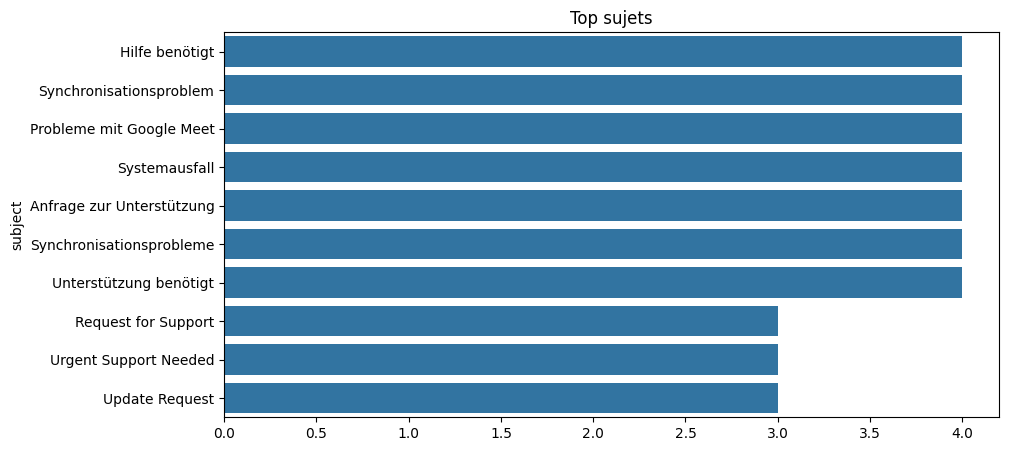

In [31]:
data["subject_length"] = data["subject"].fillna("").apply(len)

print(data["subject_length"].describe())

top_subjects = data["subject"].value_counts().head(10)
print(top_subjects)

plt.figure(figsize=(10,5))
sns.barplot(x=top_subjects.values, y=top_subjects.index)
plt.title("Top sujets")
plt.show()

Type de ticket par langue

type      Change  Incident  Problem  Request
language                                    
de          2098      8568     4493     6015
en          3149     11803     6163     8537
es            85       315      174      238
fr            52       177      109      138
pt            55       189      110      119


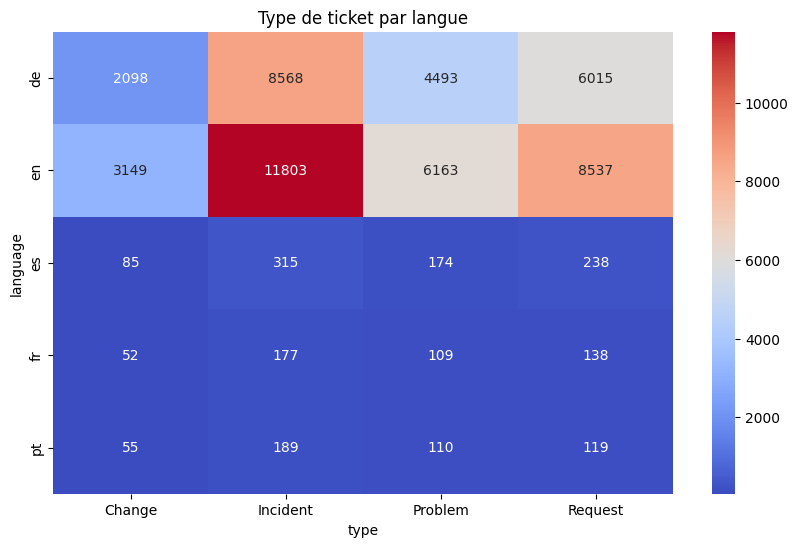

In [32]:
subject_lang = pd.crosstab(data["language"], data["type"])

print(subject_lang)

plt.figure(figsize=(10,6))
sns.heatmap(subject_lang, annot=True, fmt="d", cmap="coolwarm")
plt.title("Type de ticket par langue")
plt.show()